In [ ]:
!pip uninstall -y albumentations albucore
!pip install -q --no-cache-dir "albumentations==2.0.8"

Found existing installation: albumentations 2.0.8
Uninstalling albumentations-2.0.8:
  Successfully uninstalled albumentations-2.0.8
Found existing installation: albucore 0.0.24
Uninstalling albucore-0.0.24:
  Successfully uninstalled albucore-0.0.24
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 369.4/369.4 kB 28.6 MB/s eta 0:00:00


In [ ]:
import albumentations as A
from albumentations.pytorch import ToTensorV2
import albucore

print("Albumentations:", A.__version__)
print("Albucore:", albucore.__version__)
print("✅ Albumentations import successful!")

Albumentations: 2.0.8
Albucore: 0.0.24
✅ Albumentations import successful!


In [ ]:
import os
import io
import json
import random
import shutil
import zipfile
import warnings
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision.models import resnet101, ResNet101_Weights

import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    cohen_kappa_score, accuracy_score, f1_score, confusion_matrix, classification_report
)
from scipy.optimize import minimize

warnings.filterwarnings("ignore")
print("Imports OK.")

Imports OK.


In [ ]:
# CELL 3 — GPU verification
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
    print("GPU memory (GB):", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 2))
else:
    print("WARNING: No GPU detected. Go to Runtime > Change runtime type > GPU, then re-run.")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU name: Tesla T4
GPU memory (GB): 15.64
Using device: cuda


In [ ]:
CFG = {
    "SEED": 42,
    "IMG_SIZE": 300,
    "BATCH_SIZE": 16,
    "NUM_WORKERS": 2,
    "NUM_CLASSES": 5,
    "EPOCHS_HEAD": 5,          # phase 1: frozen backbone, head only
    "EPOCHS_FULL": 35,         # phase 2: full fine-tune, early stopping applies
    "HEAD_LR": 1e-3,
    "BACKBONE_LR": 1e-5,
    "WEIGHT_DECAY": 1e-4,
    "PATIENCE": 8,             # early stopping patience (phase 2, by val QWK)
    "MODEL_NAME": "resnet101_ordinal",
    "MIXED_PRECISION": True,
    "GRAD_ACCUM_STEPS": 1,     # increase if you need a larger effective batch size on limited GPU memory
    "TRAIN_FRAC": 0.70,
    "VAL_FRAC": 0.15,
    "TEST_FRAC": 0.15,
    "BASE_DIR": "/content/aptos_project",
    "DATASET_DIR": "/content/aptos_project/data",             # raw downloaded data lands here
    "SPLITS_DIR": "/content/aptos_project/data/splits",
    "PROCESSED_DIR": "/content/aptos_project/data/processed",
    "CHECKPOINT_DIR": "/content/aptos_project/checkpoints",
    "CHECKPOINT_PATH": "/content/aptos_project/checkpoints/best_model.pt",
    "DRIVE_BACKUP_DIR": "/content/drive/MyDrive/aptos_dr_checkpoints",  # used only if you mount Drive in Cell 6b
}

for d in [CFG["BASE_DIR"], CFG["DATASET_DIR"], CFG["SPLITS_DIR"], CFG["PROCESSED_DIR"], CFG["CHECKPOINT_DIR"]]:
    os.makedirs(d, exist_ok=True)

CLASS_NAMES = ["0-No DR", "1-Mild", "2-Moderate", "3-Severe", "4-Proliferative"]
print("Config set. Directories created under", CFG["BASE_DIR"])

Config set. Directories created under /content/aptos_project


In [ ]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(CFG["SEED"])
print(f"Seed set to {CFG['SEED']}.")

Seed set to 42.


In [ ]:
# CELL 6 — Kaggle authentication and dataset download
# Upload your kaggle.json (from kaggle.com/settings -> Create New API Token) when prompted.
from google.colab import files

kaggle_json_path = os.path.expanduser("~/.kaggle/kaggle.json")
if not os.path.exists(kaggle_json_path):
    print("Please upload your kaggle.json file now.")
    uploaded = files.upload()
    os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
    for fname in uploaded.keys():
        shutil.move(fname, kaggle_json_path)
    os.chmod(kaggle_json_path, 0o600)
    print("kaggle.json installed.")
else:
    print("kaggle.json already present, skipping upload.")

# Download the APTOS 2019 competition data (requires you to have joined the competition on Kaggle)
os.chdir(CFG["DATASET_DIR"])
!kaggle competitions download -c aptos2019-blindness-detection

# Extract
zip_path = os.path.join(CFG["DATASET_DIR"], "aptos2019-blindness-detection.zip")
if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(CFG["DATASET_DIR"])
    print("Extracted dataset.")
else:
    print("WARNING: zip not found — check that you've accepted the competition rules on Kaggle "
          "(Rules tab on the competition page) before downloading via API.")

os.chdir(CFG["BASE_DIR"])
print("\nResulting directory structure under DATASET_DIR:")
for root, dirs, filenames in os.walk(CFG["DATASET_DIR"]):
    depth = root.replace(CFG["DATASET_DIR"], "").count(os.sep)
    if depth > 2:
        continue
    indent = "  " * depth
    print(f"{indent}{os.path.basename(root)}/")
    for f in filenames[:5]:
        print(f"{indent}  {f}")

Please upload your kaggle.json file now.


Saving kaggle.json to kaggle.json
kaggle.json installed.
100% 9.51G/9.51G [01:13<00:00, 138MB/s]

Extracted dataset.

Resulting directory structure under DATASET_DIR:
data/
  train.csv
  aptos2019-blindness-detection.zip
  sample_submission.csv
  test.csv
  processed/
  train_images/
    0f96c358a250.png
    51d574513bcb.png
    25b4080f598b.png
    5d024177e214.png
    ed2c52c14493.png
  splits/
  test_images/
    06035cfbcc18.png
    5ad2ca6d422f.png
    4a6795dc22f9.png
    2677d5c9983e.png
    4a51e72940f2.png


In [ ]:
# CELL 7 — Inspect dataset
def find_file(base_dir, filename):
    for root, _, files_ in os.walk(base_dir):
        if filename in files_:
            return os.path.join(root, filename)
    return None

def find_dir(base_dir, dirname):
    for root, dirs, _ in os.walk(base_dir):
        if dirname in dirs:
            return os.path.join(root, dirname)
    return None

TRAIN_CSV_PATH = find_file(CFG["DATASET_DIR"], "train.csv")
TRAIN_IMAGES_DIR = find_dir(CFG["DATASET_DIR"], "train_images")
assert TRAIN_CSV_PATH is not None, "train.csv not found — check Cell 6 output above."
assert TRAIN_IMAGES_DIR is not None, "train_images/ not found — check Cell 6 output above."
print("train.csv:", TRAIN_CSV_PATH)
print("train_images/:", TRAIN_IMAGES_DIR)

df = pd.read_csv(TRAIN_CSV_PATH)

# Auto-detect column names if they differ from the standard APTOS naming
id_col_candidates = [c for c in df.columns if "id" in c.lower()]
label_col_candidates = [c for c in df.columns if "diagn" in c.lower() or "label" in c.lower()]
ID_COL = "id_code" if "id_code" in df.columns else (id_col_candidates[0] if id_col_candidates else df.columns[0])
LABEL_COL = "diagnosis" if "diagnosis" in df.columns else (label_col_candidates[0] if label_col_candidates else df.columns[1])
print(f"Using ID column: '{ID_COL}', label column: '{LABEL_COL}'")

df = df.rename(columns={ID_COL: "id_code", LABEL_COL: "diagnosis"})

print("\nShape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
display(df.head())
print("\nClass distribution:")
print(df["diagnosis"].value_counts().sort_index())

# Verify images exist
def resolve_image_path(img_id, images_dir):
    for ext in [".png", ".jpg", ".jpeg"]:
        p = os.path.join(images_dir, img_id + ext)
        if os.path.exists(p):
            return p
    return None

df["image_path"] = df["id_code"].apply(lambda x: resolve_image_path(x, TRAIN_IMAGES_DIR))
n_missing = df["image_path"].isna().sum()
print(f"\nImages found: {df['image_path'].notna().sum()} / {len(df)}   Missing: {n_missing}")

train.csv: /content/aptos_project/data/train.csv
train_images/: /content/aptos_project/data/train_images
Using ID column: 'id_code', label column: 'diagnosis'

Shape: (3662, 2)

Columns: ['id_code', 'diagnosis']

First 5 rows:


,id_code,diagnosis
0,000c1434d8d7,2
1,001639a390f0,4
2,0024cdab0c1e,1
3,002c21358ce6,0
4,005b95c28852,0



Class distribution:
diagnosis
0    1805
1     370
2     999
3     193
4     295
Name: count, dtype: int64

Images found: 3662 / 3662   Missing: 0


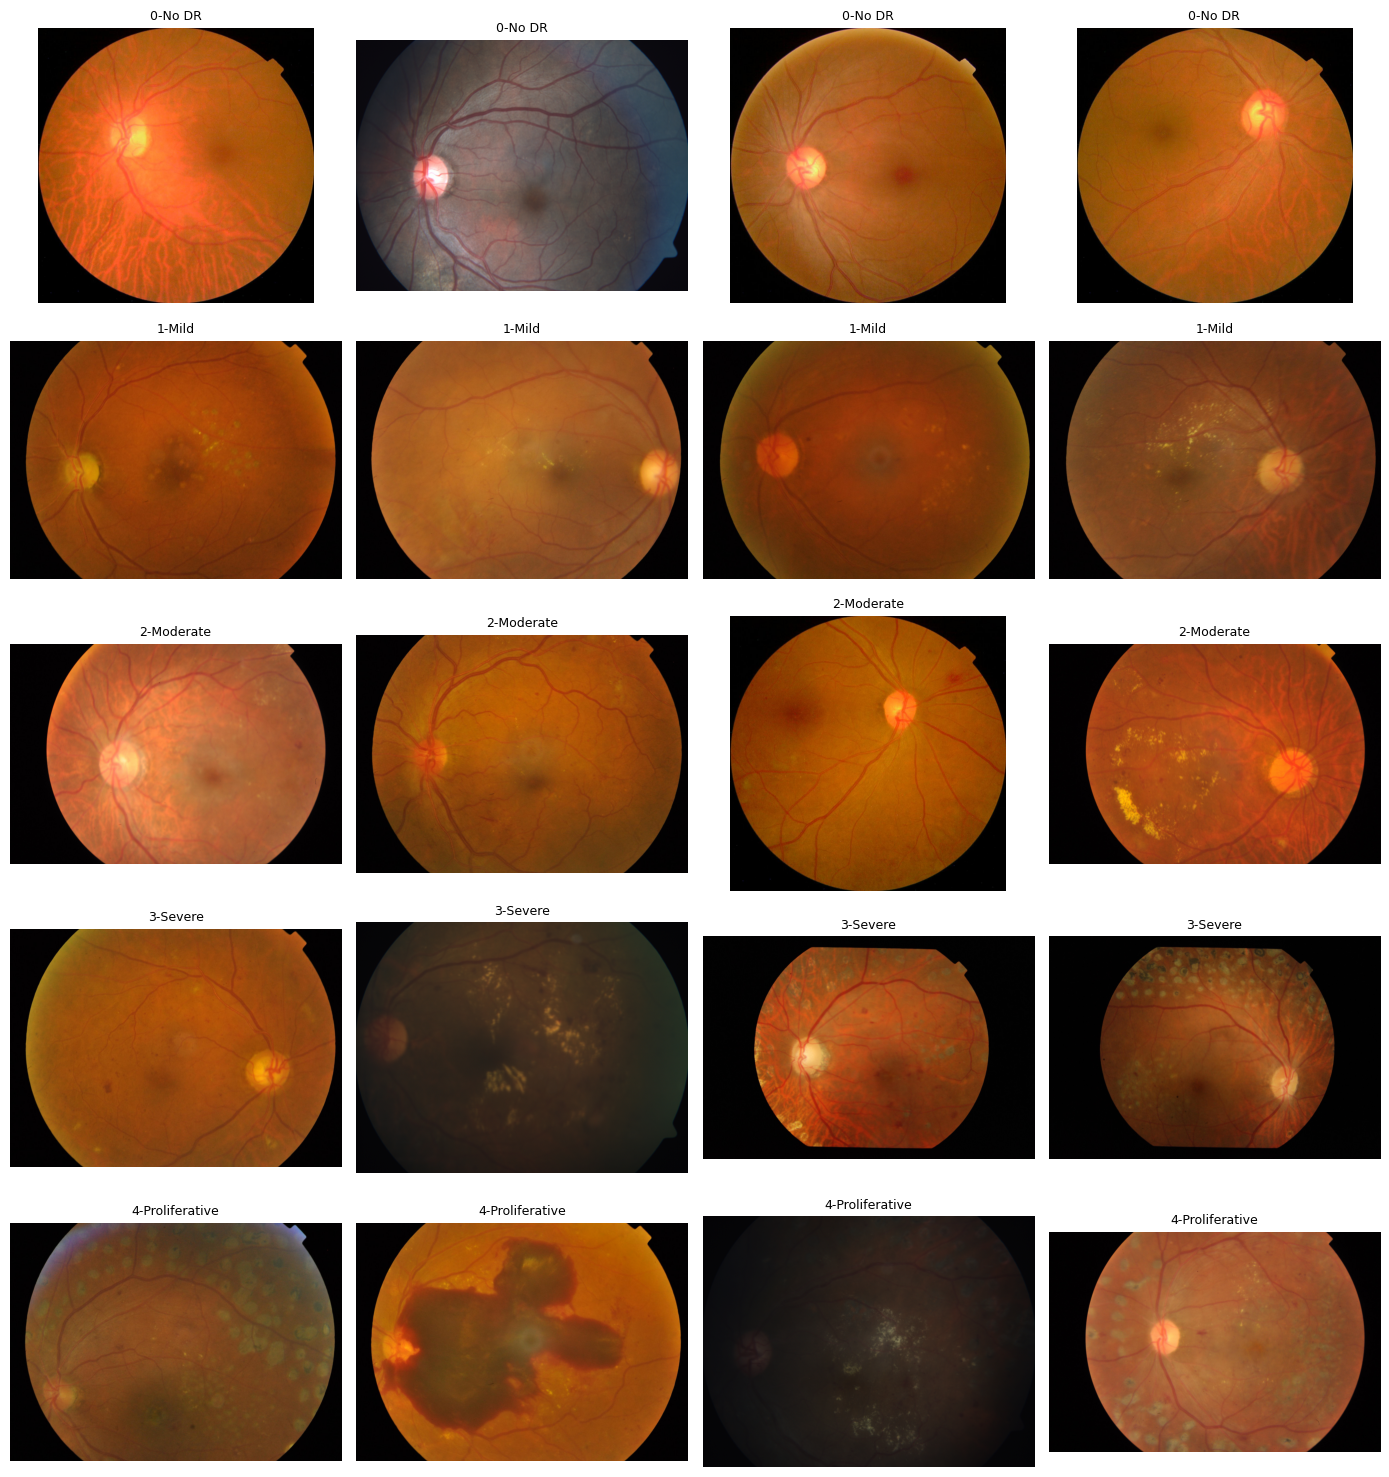

In [ ]:
fig, axes = plt.subplots(CFG["NUM_CLASSES"], 4, figsize=(14, 3 * CFG["NUM_CLASSES"]))
for cls in range(CFG["NUM_CLASSES"]):
    samples = df[df["diagnosis"] == cls].dropna(subset=["image_path"]).sample(
        min(4, (df["diagnosis"] == cls).sum()), random_state=CFG["SEED"]
    )
    for j, (_, row) in enumerate(samples.iterrows()):
        img = cv2.cvtColor(cv2.imread(row["image_path"]), cv2.COLOR_BGR2RGB)
        ax = axes[cls, j] if CFG["NUM_CLASSES"] > 1 else axes[j]
        ax.imshow(img)
        ax.set_title(f"{CLASS_NAMES[cls]}", fontsize=9)
        ax.axis("off")
    for j in range(len(samples), 4):
        ax = axes[cls, j] if CFG["NUM_CLASSES"] > 1 else axes[j]
        ax.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
# CELL 9 — Data cleaning: missing images, corrupted files, duplicate IDs, invalid labels
before = len(df)

# Missing images
df_clean = df.dropna(subset=["image_path"]).copy()

# Corrupted images (fails to load / decode)
def is_readable(path):
    img = cv2.imread(path)
    return img is not None and img.size > 0

tqdm.pandas(desc="Checking image integrity")
df_clean["readable"] = df_clean["image_path"].progress_apply(is_readable)
n_corrupt = (~df_clean["readable"]).sum()
df_clean = df_clean[df_clean["readable"]].drop(columns=["readable"])

# Duplicate id_code rows
n_dupes = df_clean["id_code"].duplicated().sum()
df_clean = df_clean.drop_duplicates(subset=["id_code"], keep="first")

# Invalid labels (must be an int in [0, NUM_CLASSES-1])
valid_labels = set(range(CFG["NUM_CLASSES"]))
n_invalid_label = (~df_clean["diagnosis"].isin(valid_labels)).sum()
df_clean = df_clean[df_clean["diagnosis"].isin(valid_labels)]
df_clean["diagnosis"] = df_clean["diagnosis"].astype(int)

print(f"Started with {before} rows.")
print(f"Removed missing-image rows: {before - len(df.dropna(subset=['image_path']))}")
print(f"Removed corrupted images: {n_corrupt}")
print(f"Removed duplicate id_code rows: {n_dupes}")
print(f"Removed invalid-label rows: {n_invalid_label}")
print(f"Remaining after cleaning: {len(df_clean)}")

df = df_clean.reset_index(drop=True)

Checking image integrity:   0%|          | 0/3662 [00:00<?, ?it/s]

Started with 3662 rows.
Removed missing-image rows: 0
Removed corrupted images: 0
Removed duplicate id_code rows: 0
Removed invalid-label rows: 0
Remaining after cleaning: 3662


In [ ]:
# CELL 10 — Stratified train/val/test split (70/15/15), saved for reuse, no overlap
train_val_df, test_df = train_test_split(
    df, test_size=CFG["TEST_FRAC"], stratify=df["diagnosis"], random_state=CFG["SEED"]
)
val_frac_adjusted = CFG["VAL_FRAC"] / (1 - CFG["TEST_FRAC"])
train_df, val_df = train_test_split(
    train_val_df, test_size=val_frac_adjusted, stratify=train_val_df["diagnosis"], random_state=CFG["SEED"]
)

train_df.to_csv(os.path.join(CFG["SPLITS_DIR"], "train_split.csv"), index=False)
val_df.to_csv(os.path.join(CFG["SPLITS_DIR"], "val_split.csv"), index=False)
test_df.to_csv(os.path.join(CFG["SPLITS_DIR"], "test_split.csv"), index=False)

for name, split in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    print(f"\n{name}: n={len(split)}")
    print(split["diagnosis"].value_counts(normalize=True).sort_index().round(3))

# Verify zero overlap between splits
train_ids, val_ids, test_ids = set(train_df["id_code"]), set(val_df["id_code"]), set(test_df["id_code"])
assert not (train_ids & val_ids), "Overlap between train and val!"
assert not (train_ids & test_ids), "Overlap between train and test!"
assert not (val_ids & test_ids), "Overlap between val and test!"
print("\nVerified: no overlap between train/val/test splits.")


Train: n=2562
diagnosis
0    0.493
1    0.101
2    0.273
3    0.053
4    0.081
Name: proportion, dtype: float64

Val: n=550
diagnosis
0    0.493
1    0.102
2    0.273
3    0.053
4    0.080
Name: proportion, dtype: float64

Test: n=550
diagnosis
0    0.493
1    0.102
2    0.273
3    0.053
4    0.080
Name: proportion, dtype: float64

Verified: no overlap between train/val/test splits.


In [ ]:
#CELL 11 — Deterministic preprocessing pipeline for fundus images
# (same transform used for train/val/test; only used to prepare a clean base image,
#  before Albumentations augmentation is applied on top in Cell 12/13)

def circular_crop(img, tol=7):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    mask = gray > tol
    if mask.sum() == 0:
        return img
    coords = np.argwhere(mask)
    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0) + 1
    return img[y0:y1, x0:x1]

def ben_graham_normalize(img, sigma_frac=10):
    sigma = img.shape[1] / sigma_frac
    blurred = cv2.GaussianBlur(img, (0, 0), sigma)
    return cv2.addWeighted(img, 4, blurred, -4, 128)

def apply_clahe(img, clip_limit=2.0, tile_grid_size=(8, 8)):
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    l2 = clahe.apply(l)
    merged = cv2.merge((l2, a, b))
    return cv2.cvtColor(merged, cv2.COLOR_LAB2BGR)

def circular_mask(img):
    h, w = img.shape[:2]
    mask = np.zeros((h, w), dtype=np.uint8)
    cv2.circle(mask, (w // 2, h // 2), min(h, w) // 2, 255, -1)
    return cv2.bitwise_and(img, img, mask=mask)

def preprocess_image(path, size=CFG["IMG_SIZE"]):
    img = cv2.imread(path)
    img = circular_crop(img)
    img = cv2.resize(img, (size, size), interpolation=cv2.INTER_AREA)
    img = circular_mask(img)
    img = ben_graham_normalize(img)
    img = apply_clahe(img)
    return img

def process_and_cache_split(split_df, out_dir):
    os.makedirs(out_dir, exist_ok=True)
    for _, row in tqdm(split_df.iterrows(), total=len(split_df), desc=f"Preprocessing -> {out_dir}"):
        out_path = os.path.join(out_dir, row["id_code"] + ".png")
        if os.path.exists(out_path):
            continue
        processed = preprocess_image(row["image_path"])
        cv2.imwrite(out_path, processed)

process_and_cache_split(train_df, os.path.join(CFG["PROCESSED_DIR"], "train_split"))
process_and_cache_split(val_df, os.path.join(CFG["PROCESSED_DIR"], "val_split"))
process_and_cache_split(test_df, os.path.join(CFG["PROCESSED_DIR"], "test_split"))
print("Preprocessing complete. Cached processed images on disk.")

Preprocessing -> /content/aptos_project/data/processed/train_split:   0%|          | 0/2562 [00:00<?, ?it/s]

Preprocessing -> /content/aptos_project/data/processed/val_split:   0%|          | 0/550 [00:00<?, ?it/s]

Preprocessing -> /content/aptos_project/data/processed/test_split:   0%|          | 0/550 [00:00<?, ?it/s]

Preprocessing complete. Cached processed images on disk.


In [ ]:
# CELL 12 — Augmentation pipelines
# Train: medically reasonable augmentation only (no distortions that fake/erase pathology).
# Val/Test: deterministic, no randomness.
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = A.Compose([
    A.Resize(CFG["IMG_SIZE"], CFG["IMG_SIZE"]),
    A.Rotate(limit=180, p=0.8, border_mode=cv2.BORDER_CONSTANT),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=0, p=0.4, border_mode=cv2.BORDER_CONSTANT),
    A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.5),
    A.GaussianBlur(blur_limit=(3, 3), p=0.1),
    A.CoarseDropout(max_holes=4, max_height=20, max_width=20, p=0.2),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

eval_transform = A.Compose([
    A.Resize(CFG["IMG_SIZE"], CFG["IMG_SIZE"]),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

print("Augmentation pipelines ready.")

Augmentation pipelines ready.


In [ ]:
# CELL 13 — PyTorch Dataset class
class APTOSDataset(Dataset):
    def __init__(self, split_df, processed_dir, transform=None):
        self.df = split_df.reset_index(drop=True)
        self.processed_dir = processed_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path = os.path.join(self.processed_dir, row["id_code"] + ".png")
        try:
            img = cv2.imread(path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        except Exception:
            # Robust fallback: return a black image rather than crashing the run
            img = np.zeros((CFG["IMG_SIZE"], CFG["IMG_SIZE"], 3), dtype=np.uint8)
        if self.transform:
            img = self.transform(image=img)["image"]
        label = float(row["diagnosis"])  # float target for ordinal regression
        return img, label

print("Dataset class defined.")

Dataset class defined.


In [ ]:
# CELL 14 — DataLoaders (train uses a weighted sampler to oversample minority classes)
train_ds = APTOSDataset(train_df, os.path.join(CFG["PROCESSED_DIR"], "train_split"), transform=train_transform)
val_ds = APTOSDataset(val_df, os.path.join(CFG["PROCESSED_DIR"], "val_split"), transform=eval_transform)
test_ds = APTOSDataset(test_df, os.path.join(CFG["PROCESSED_DIR"], "test_split"), transform=eval_transform)

class_counts = train_df["diagnosis"].value_counts().sort_index().reindex(range(CFG["NUM_CLASSES"]), fill_value=1)
sample_weights = train_df["diagnosis"].map(1.0 / class_counts).values
sampler = WeightedRandomSampler(weights=torch.DoubleTensor(sample_weights), num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=CFG["BATCH_SIZE"], sampler=sampler,
                           num_workers=CFG["NUM_WORKERS"], pin_memory=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=CFG["BATCH_SIZE"], shuffle=False,
                         num_workers=CFG["NUM_WORKERS"], pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=CFG["BATCH_SIZE"], shuffle=False,
                          num_workers=CFG["NUM_WORKERS"], pin_memory=True)

print(f"train_loader: {len(train_ds)} images, {len(train_loader)} batches (weighted sampling)")
print(f"val_loader:   {len(val_ds)} images, {len(val_loader)} batches")
print(f"test_loader:  {len(test_ds)} images, {len(test_loader)} batches")

train_loader: 2562 images, 160 batches (weighted sampling)
val_loader:   550 images, 35 batches
test_loader:  550 images, 35 batches


In [ ]:
# CELL 15 — Model: ResNet101 with a single-output ordinal regression head.
# Rationale: plain 5-way softmax with categorical cross-entropy treats every wrong class
# as equally wrong, which produces the classic "adjacent-class bleed" (0<->1, 1<->2, ...)
# seen on this ordinal, imbalanced dataset. A single continuous output trained with MSE
# naturally penalizes far-off errors more than near-off ones, matching Quadratic Weighted
# Kappa's own scoring logic.
def build_model(pretrained=True, dropout=0.3):
    weights = ResNet101_Weights.IMAGENET1K_V2 if pretrained else None
    model = resnet101(weights=weights)
    in_features = model.fc.in_features
    model.fc = nn.Sequential(nn.Dropout(p=dropout), nn.Linear(in_features, 1))
    return model

def freeze_backbone(model):
    for name, p in model.named_parameters():
        if not name.startswith("fc."):
            p.requires_grad = False

def unfreeze_all(model):
    for p in model.parameters():
        p.requires_grad = True

def discriminative_param_groups(model, head_lr, backbone_lr):
    backbone_params, head_params = [], []
    for name, p in model.named_parameters():
        (head_params if name.startswith("fc.") else backbone_params).append(p)
    return [{"params": backbone_params, "lr": backbone_lr}, {"params": head_params, "lr": head_lr}]

model = build_model(pretrained=True).to(DEVICE)
print(f"Model built: ResNet101 ordinal regression head, {sum(p.numel() for p in model.parameters()):,} parameters.")

Downloading: "https://download.pytorch.org/models/resnet101-cd907fc2.pth" to /root/.cache/torch/hub/checkpoints/resnet101-cd907fc2.pth


100%|██████████| 171M/171M [00:01<00:00, 163MB/s]


Model built: ResNet101 ordinal regression head, 42,502,209 parameters.


In [ ]:
# CELL 16 — Loss, optimizer, scheduler
criterion = nn.MSELoss()

scaler = torch.cuda.amp.GradScaler(enabled=CFG["MIXED_PRECISION"])

def make_optimizer(model, phase):
    if phase == "head":
        return torch.optim.AdamW(
            [p for p in model.parameters() if p.requires_grad],
            lr=CFG["HEAD_LR"], weight_decay=CFG["WEIGHT_DECAY"]
        )
    else:
        return torch.optim.AdamW(
            discriminative_param_groups(model, CFG["HEAD_LR"], CFG["BACKBONE_LR"]),
            weight_decay=CFG["WEIGHT_DECAY"]
        )

print("Loss (MSE), AdamW optimizer factory, and AMP GradScaler ready.")

Loss (MSE), AdamW optimizer factory, and AMP GradScaler ready.


In [ ]:
# CELL 17 — Training loop: Phase 1 (frozen backbone, head only) then Phase 2
# (full fine-tune, discriminative LR, early stopping on VALIDATION quadratic kappa).
# The test set is never touched in this cell.

def predictions_to_classes(preds, thresholds=(0.5, 1.5, 2.5, 3.5)):
    preds = np.asarray(preds)
    classes = np.digitize(preds, thresholds)
    return np.clip(classes, 0, CFG["NUM_CLASSES"] - 1)

@torch.no_grad()
def evaluate_epoch(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    for imgs, labels in loader:
        imgs = imgs.to(DEVICE)
        with torch.cuda.amp.autocast(enabled=CFG["MIXED_PRECISION"]):
            outputs = model(imgs).squeeze(1)
        all_preds.extend(outputs.float().cpu().numpy())
        all_labels.extend(labels.numpy())
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels).astype(int)
    pred_classes = predictions_to_classes(all_preds)
    kappa = cohen_kappa_score(all_labels, pred_classes, weights="quadratic")
    acc = accuracy_score(all_labels, pred_classes)
    return kappa, acc, all_preds, all_labels

def train_one_epoch(model, loader, optimizer):
    model.train()
    running_loss = 0.0
    optimizer.zero_grad()
    for step, (imgs, labels) in enumerate(tqdm(loader, desc="train", leave=False)):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE).float()
        with torch.cuda.amp.autocast(enabled=CFG["MIXED_PRECISION"]):
            outputs = model(imgs).squeeze(1)
            loss = criterion(outputs, labels) / CFG["GRAD_ACCUM_STEPS"]
        scaler.scale(loss).backward()
        if (step + 1) % CFG["GRAD_ACCUM_STEPS"] == 0:
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()
        running_loss += loss.item() * imgs.size(0) * CFG["GRAD_ACCUM_STEPS"]
    return running_loss / len(loader.dataset)

history = {"train_loss": [], "val_kappa": [], "val_acc": []}
best_kappa = -1.0
patience_counter = 0

# ---- Phase 1: frozen backbone, head only ----
freeze_backbone(model)
optimizer = make_optimizer(model, phase="head")
print(f"\n=== Phase 1: training head only for {CFG['EPOCHS_HEAD']} epochs ===")
for epoch in range(CFG["EPOCHS_HEAD"]):
    train_loss = train_one_epoch(model, train_loader, optimizer)
    val_kappa, val_acc, _, _ = evaluate_epoch(model, val_loader)
    history["train_loss"].append(train_loss)
    history["val_kappa"].append(val_kappa)
    history["val_acc"].append(val_acc)
    print(f"[head] epoch {epoch+1}/{CFG['EPOCHS_HEAD']}  train_loss={train_loss:.4f}  "
          f"val_kappa={val_kappa:.4f}  val_acc={val_acc:.4f}")
    if val_kappa > best_kappa:
        best_kappa = val_kappa
        torch.save({"model_state_dict": model.state_dict(), "epoch": epoch, "phase": "head",
                    "val_kappa": val_kappa, "val_acc": val_acc}, CFG["CHECKPOINT_PATH"])

# ---- Phase 2: full fine-tune, discriminative LR, early stopping ----
unfreeze_all(model)
optimizer = make_optimizer(model, phase="full")
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=3)
print(f"\n=== Phase 2: full fine-tune for up to {CFG['EPOCHS_FULL']} epochs (early stop patience={CFG['PATIENCE']}) ===")
for epoch in range(CFG["EPOCHS_FULL"]):
    train_loss = train_one_epoch(model, train_loader, optimizer)
    val_kappa, val_acc, _, _ = evaluate_epoch(model, val_loader)
    scheduler.step(val_kappa)
    history["train_loss"].append(train_loss)
    history["val_kappa"].append(val_kappa)
    history["val_acc"].append(val_acc)
    print(f"[full] epoch {epoch+1}/{CFG['EPOCHS_FULL']}  train_loss={train_loss:.4f}  "
          f"val_kappa={val_kappa:.4f}  val_acc={val_acc:.4f}")
    if val_kappa > best_kappa:
        best_kappa = val_kappa
        patience_counter = 0
        torch.save({"model_state_dict": model.state_dict(), "epoch": epoch, "phase": "full",
                    "val_kappa": val_kappa, "val_acc": val_acc}, CFG["CHECKPOINT_PATH"])
        print(f"  -> new best checkpoint saved (val_kappa={val_kappa:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= CFG["PATIENCE"]:
            print(f"Early stopping at epoch {epoch+1} (no val_kappa improvement for {CFG['PATIENCE']} epochs).")
            break

print(f"\nTraining complete. Best validation quadratic kappa: {best_kappa:.4f}")
print(f"Best checkpoint: {CFG['CHECKPOINT_PATH']}")


=== Phase 1: training head only for 5 epochs ===


train:   0%|          | 0/160 [00:00<?, ?it/s]

[head] epoch 1/5  train_loss=1.6839  val_kappa=0.6685  val_acc=0.4291


train:   0%|          | 0/160 [00:00<?, ?it/s]

[head] epoch 2/5  train_loss=1.0907  val_kappa=0.7427  val_acc=0.5691


...

[full] epoch 21/35  train_loss=0.2754  val_kappa=0.8645  val_acc=0.7200


train:   0%|          | 0/160 [00:00<?, ?it/s]

[full] epoch 22/35  train_loss=0.2887  val_kappa=0.8711  val_acc=0.7218


train:   0%|          | 0/160 [00:00<?, ?it/s]

[full] epoch 23/35  train_loss=0.2530  val_kappa=0.8735  val_acc=0.7164
Early stopping at epoch 23 (no val_kappa improvement for 8 epochs).

Training complete. Best validation quadratic kappa: 0.8787
Best checkpoint: /content/aptos_project/checkpoints/best_model.pt


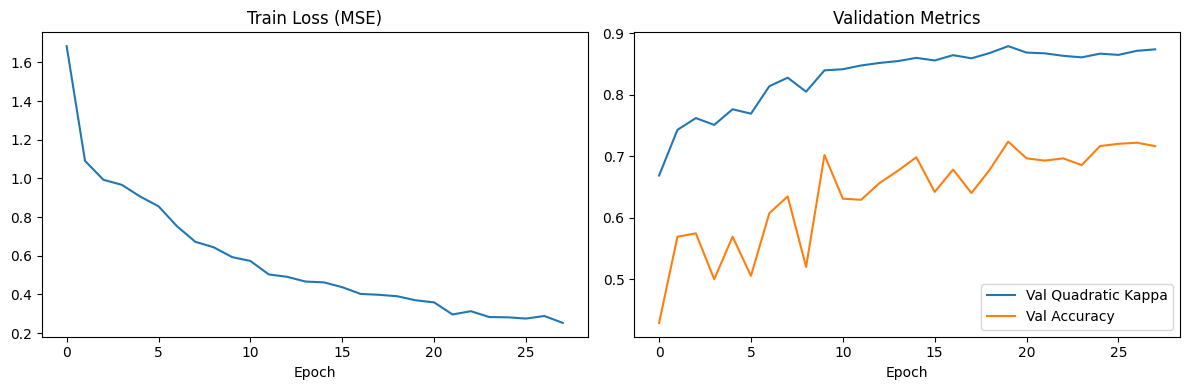

In [ ]:
# CELL 18 — Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history["train_loss"])
axes[0].set_title("Train Loss (MSE)")
axes[0].set_xlabel("Epoch")
axes[1].plot(history["val_kappa"], label="Val Quadratic Kappa")
axes[1].plot(history["val_acc"], label="Val Accuracy")
axes[1].set_title("Validation Metrics")
axes[1].set_xlabel("Epoch")
axes[1].legend()
plt.tight_layout()
plt.show()

In [ ]:
# CELL 19 — Optimize rounding thresholds on VALIDATION set only (never on test).
# Naive round() at .5 boundaries is arbitrary; this finds the four cut points that
# maximize quadratic kappa on validation data. Standard, leakage-safe calibration
# technique (used by top Kaggle DR solutions) — not test-set threshold gaming.
import torch

checkpoint = torch.load(
    CFG["CHECKPOINT_PATH"],
    map_location=DEVICE,
    weights_only=False
)

model.load_state_dict(checkpoint["model_state_dict"])

print(
    f"Loaded best checkpoint "
    f"(phase={checkpoint.get('phase', 'N/A')}, "
    f"epoch={checkpoint.get('epoch', 'N/A')}, "
    f"val_qwk={checkpoint.get('val_qwk', 'N/A')})"
)

_, _, val_preds_raw, val_labels = evaluate_epoch(model, val_loader)

def neg_kappa_for_thresholds(thresholds, preds, labels):
    thresholds = np.sort(thresholds)
    classes = predictions_to_classes(preds, thresholds)
    return -cohen_kappa_score(labels, classes, weights="quadratic")

initial_thresholds = [0.5, 1.5, 2.5, 3.5]
result = minimize(neg_kappa_for_thresholds, initial_thresholds, args=(val_preds_raw, val_labels), method="Nelder-Mead")
optimized_thresholds = tuple(np.sort(result.x))
print("Optimized thresholds (from default 0.5/1.5/2.5/3.5):", [round(t, 3) for t in optimized_thresholds])

val_kappa_default = -neg_kappa_for_thresholds(initial_thresholds, val_preds_raw, val_labels)
val_kappa_optimized = -result.fun
print(f"Val QWK with default thresholds:   {val_kappa_default:.4f}")
print(f"Val QWK with optimized thresholds: {val_kappa_optimized:.4f}")

Loaded best checkpoint (phase=full, epoch=14, val_qwk=N/A)
Optimized thresholds (from default 0.5/1.5/2.5/3.5): [np.float64(0.519), np.float64(1.51), np.float64(2.49), np.float64(3.522)]
Val QWK with default thresholds:   0.8787
Val QWK with optimized thresholds: 0.8833


In [ ]:
# CELL 20 — Test-time augmentation (TTA): average predictions across simple flips/rotation.
tta_transform_variants = [
    eval_transform,  # identity
    A.Compose([A.Resize(CFG["IMG_SIZE"], CFG["IMG_SIZE"]), A.HorizontalFlip(p=1.0),
               A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD), ToTensorV2()]),
    A.Compose([A.Resize(CFG["IMG_SIZE"], CFG["IMG_SIZE"]), A.VerticalFlip(p=1.0),
               A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD), ToTensorV2()]),
    A.Compose([A.Resize(CFG["IMG_SIZE"], CFG["IMG_SIZE"]), A.Rotate(limit=(15, 15), p=1.0, border_mode=cv2.BORDER_CONSTANT),
               A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD), ToTensorV2()]),
]

@torch.no_grad()
def predict_with_tta(model, split_df, processed_dir):
    model.eval()
    all_preds = []
    for _, row in tqdm(split_df.iterrows(), total=len(split_df), desc="TTA inference"):
        path = os.path.join(processed_dir, row["id_code"] + ".png")
        img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
        variant_preds = []
        for t in tta_transform_variants:
            tensor = t(image=img)["image"].unsqueeze(0).to(DEVICE)
            with torch.cuda.amp.autocast(enabled=CFG["MIXED_PRECISION"]):
                out = model(tensor).squeeze().item()
            variant_preds.append(out)
        all_preds.append(np.mean(variant_preds))
    return np.array(all_preds)

print("TTA inference function ready (used in the final test evaluation cell).")

TTA inference function ready (used in the final test evaluation cell).


TTA inference:   0%|          | 0/550 [00:00<?, ?it/s]

FINAL HELD-OUT TEST RESULTS (n = 550 )
Accuracy:              0.7418
Quadratic Weighted Kappa: 0.8717
Macro F1:               0.5511


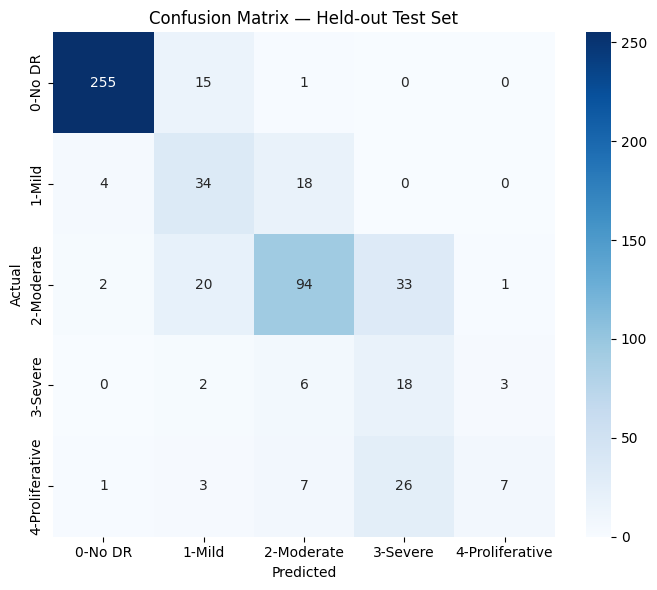


Per-class sensitivity / specificity:
  0-No DR              sensitivity=0.941  specificity=0.975  (n=271)
  1-Mild               sensitivity=0.607  specificity=0.919  (n=56)
  2-Moderate           sensitivity=0.627  specificity=0.920  (n=150)
  3-Severe             sensitivity=0.621  specificity=0.887  (n=29)
  4-Proliferative      sensitivity=0.159  specificity=0.992  (n=44)

Full classification report:
                 precision    recall  f1-score   support

        0-No DR      0.973     0.941     0.957       271
         1-Mild      0.459     0.607     0.523        56
     2-Moderate      0.746     0.627     0.681       150
       3-Severe      0.234     0.621     0.340        29
4-Proliferative      0.636     0.159     0.255        44

       accuracy                          0.742       550
      macro avg      0.610     0.591     0.551       550
   weighted avg      0.793     0.742     0.749       550


NOTE: this evaluation reflects APTOS 2019 only. It does not establish cros

In [ ]:
# CELL 21 — FINAL TEST EVALUATION. Run once. Test set has not been touched until this cell.
test_preds_raw = predict_with_tta(model, test_df, os.path.join(CFG["PROCESSED_DIR"], "test_split"))
test_labels = test_df["diagnosis"].values.astype(int)
test_pred_classes = predictions_to_classes(test_preds_raw, optimized_thresholds)

test_acc = accuracy_score(test_labels, test_pred_classes)
test_kappa = cohen_kappa_score(test_labels, test_pred_classes, weights="quadratic")
test_macro_f1 = f1_score(test_labels, test_pred_classes, average="macro")
cm = confusion_matrix(test_labels, test_pred_classes, labels=list(range(CFG["NUM_CLASSES"])))

print("=" * 60)
print("FINAL HELD-OUT TEST RESULTS (n =", len(test_labels), ")")
print("=" * 60)
print(f"Accuracy:              {test_acc:.4f}")
print(f"Quadratic Weighted Kappa: {test_kappa:.4f}")
print(f"Macro F1:               {test_macro_f1:.4f}")

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Held-out Test Set")
plt.tight_layout()
plt.show()

print("\nPer-class sensitivity / specificity:")
total = cm.sum()
for i, name in enumerate(CLASS_NAMES):
    tp = cm[i, i]
    fn = cm[i, :].sum() - tp
    fp = cm[:, i].sum() - tp
    tn = total - tp - fn - fp
    sens = tp / (tp + fn) if (tp + fn) > 0 else float("nan")
    spec = tn / (tn + fp) if (tn + fp) > 0 else float("nan")
    print(f"  {name:20s} sensitivity={sens:.3f}  specificity={spec:.3f}  (n={tp+fn})")

print("\nFull classification report:")
print(classification_report(test_labels, test_pred_classes, target_names=CLASS_NAMES, digits=3))

print("\nNOTE: this evaluation reflects APTOS 2019 only. It does not establish cross-dataset\n"
      "generalization (different camera/population) or clinical validity. Classes 3/4 have\n"
      "few test examples, so their sensitivity/specificity figures carry wide uncertainty —\n"
      "report them as measured, not smoothed over.")

In [ ]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

def get_eval_transforms(img_size):
    return A.Compose([
        A.Resize(img_size, img_size),
        A.Normalize(
            mean=(0.485, 0.456, 0.406),
            std=(0.229, 0.224, 0.225)
        ),
        ToTensorV2()
    ])

In [ ]:
# Quick sanity check: load the checkpoint and predict on one known test image
ckpt = torch.load(CFG["CHECKPOINT_PATH"], map_location=DEVICE,weights_only=False)
check_model = build_model(pretrained=False).to(DEVICE)
check_model.load_state_dict(ckpt["model_state_dict"])
check_model.eval()

sample_row = test_df.iloc[0]
img_path = os.path.join(CFG["PROCESSED_DIR"], "test_split", sample_row["id_code"] + ".png")
img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
tensor = get_eval_transforms(CFG["IMG_SIZE"])(image=img)["image"].unsqueeze(0).to(DEVICE)

with torch.no_grad():
    raw_score = check_model(tensor).squeeze().item()

thresholds = ckpt["optimized_thresholds"]
pred_class = sum(raw_score > t for t in thresholds)

print(f"True label: {int(sample_row['diagnosis'])}")
print(f"Predicted:  {pred_class}  (raw score: {raw_score:.3f})")

True label: 0
Predicted:  0  (raw score: 0.131)


In [ ]:
!pip freeze > requirements_colab.txt

In [ ]:
# CELL 22 — Save final checkpoint + config + thresholds (and optionally back up to Drive)
final_package = {
    "model_state_dict": model.state_dict(),
    "config": CFG,
    "optimized_thresholds": optimized_thresholds,
    "test_accuracy": test_acc,
    "test_quadratic_kappa": test_kappa,
    "test_macro_f1": test_macro_f1,
}
torch.save(final_package, CFG["CHECKPOINT_PATH"])
print(f"Final package saved to {CFG['CHECKPOINT_PATH']}")

# Optional: back up to Google Drive (requires drive.mount from Cell 6b)
# os.makedirs(CFG["DRIVE_BACKUP_DIR"], exist_ok=True)
# shutil.copy(CFG["CHECKPOINT_PATH"], CFG["DRIVE_BACKUP_DIR"])
# print(f"Backed up to {CFG['DRIVE_BACKUP_DIR']}")

# To reload later:
# ckpt = torch.load(CFG["CHECKPOINT_PATH"], map_location=DEVICE)
# model = build_model(pretrained=False).to(DEVICE)
# model.load_state_dict(ckpt["model_state_dict"])
# thresholds = ckpt["optimized_thresholds"]

Final package saved to /content/aptos_project/checkpoints/best_model.pt


In [ ]:
!pip install -q grad-cam

In [ ]:
import torch
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

print("Grad-CAM imported successfully!")

Grad-CAM imported successfully!


In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

# ResNet101 final convolutional block
target_layers = [model.layer4[-1]]

cam = GradCAM(
    model=model,
    target_layers=target_layers
)

def show_gradcam(split_df, processed_dir, n=6):
    model.eval()

    samples = split_df.sample(
        n=min(n, len(split_df)),
        random_state=CFG["SEED"]
    )

    fig, axes = plt.subplots(
        len(samples),
        2,
        figsize=(10, 5 * len(samples))
    )

    if len(samples) == 1:
        axes = np.expand_dims(axes, axis=0)

    for row, (_, sample) in enumerate(samples.iterrows()):

        image_id = sample["id_code"]
        image_path = os.path.join(
            processed_dir,
            image_id + ".png"
        )

        img = cv2.imread(image_path)

        if img is None:
            print(f"Could not read: {image_path}")
            continue

        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        img_float = cv2.resize(
            img_rgb,
            (CFG["IMG_SIZE"], CFG["IMG_SIZE"])
        ).astype(np.float32) / 255.0

        transformed = eval_transform(image=img_rgb)

        tensor = (
            transformed["image"]
            .unsqueeze(0)
            .to(DEVICE)
        )

        # Get model prediction
        with torch.no_grad():
            output = model(tensor)
            predicted_class = output.argmax(dim=1).item()

        # Explicit Grad-CAM target
        targets = [ClassifierOutputTarget(predicted_class)]

        grayscale_cam = cam(
            input_tensor=tensor,
            targets=targets
        )[0]

        visualization = show_cam_on_image(
            img_float,
            grayscale_cam,
            use_rgb=True
        )

        true_class = int(sample["diagnosis"])

        axes[row, 0].imshow(img_rgb)
        axes[row, 0].set_title(
            f"Original\nTrue: {true_class} | Predicted: {predicted_class}"
        )
        axes[row, 0].axis("off")

        axes[row, 1].imshow(visualization)
        axes[row, 1].set_title(
            f"Grad-CAM\nPredicted class: {predicted_class}"
        )
        axes[row, 1].axis("off")

    plt.tight_layout()
    plt.show()

In [ ]:
from google.colab import files

files.download("/content/aptos_project/requirements_colab.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>